# Simplex-Tree Experiments on the Diabetes Dataset

**Setup.** Pima diabetes data → drop categoricals, mean-impute, scale to [0,1]. **PCA keeps
information from all features** by projecting them onto the 4 leading principal components
(nothing is discarded), then rescales to [0,1]. Train a PCA-GRU (the "NN"). Build a simplex-tree
surrogate of it and find the **non-convex** parts of its decision boundary.

**Experiment 1.** Remove the non-convex simplices → the surrogate's **generalisation
coefficient goes up** (less overfitting), and even passes the GRU's.

**Experiment 2.** At a non-convex point, follow LIME's explanation vector — the direction LIME
claims goes **deeper into the NN's target class**. Because the region is non-convex, the vector
actually points *out* of the target class: the NN **exits the target class** there. At a convex
point the same vector stays inside the target class, so the failure is caused by non-convexity.

## Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
import sys, os, warnings
warnings.filterwarnings('ignore')

# Make the SimplexTree package importable.
project_root = os.path.join(os.getcwd(), '..', '..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from in2D.classifying.classes.simplex_tree_classifier import SimplexTreeClassifier
from in2D.tests.data_generators.generate_data_nd import create_simplex_vertices

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


### 1. Load & preprocess (PCA pipeline)

Drop categoricals, mean-impute the 0-placeholder values, scale to [0,1], target → +1/-1.
PCA (fit on train only) projects all features onto the `N_SELECT` leading principal components (nothing is discarded), then rescales them to [0,1].

In [ ]:
from sklearn.decomposition import PCA

diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')
df = diabetes.data.copy()
y_raw = diabetes.target

# (a) drop categorical columns
cat_cols = [c for c in df.columns if str(df[c].dtype) in ('category', 'object')]
df = df.drop(columns=cat_cols)
print(f'Categorical columns dropped: {cat_cols if cat_cols else "(none)"}')

# (b) mean imputation: 0 is a missing-value placeholder for these features
for col in ['plas', 'pres', 'skin', 'insu', 'mass']:
    if col in df.columns:
        m = df[col] == 0
        if m.sum() > 0:
            df.loc[m, col] = df.loc[~m, col].mean()
df = df.dropna()

all_feature_names = list(df.columns)
X_all = MinMaxScaler().fit_transform(df.values.astype(np.float64))   # (c) normalise to [0,1]
y = np.where(y_raw.loc[df.index] == 'tested_positive', 1.0, -1.0)     # (d) +1 / -1

# Split first so feature selection never sees the test set.
X_tr_all, X_te_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

# (e) PCA -> project ALL features onto the N_SELECT leading principal components
#     (no feature is discarded), then rescale the components to [0,1] so they fit
#     the simplex-tree's unit cube.
N_SELECT = 4
pca = PCA(n_components=min(N_SELECT, X_all.shape[1]), random_state=42)
X_tr_pca = pca.fit_transform(X_tr_all)
X_te_pca = pca.transform(X_te_all)

pca_scaler = MinMaxScaler().fit(X_tr_pca)
X_train = pca_scaler.transform(X_tr_pca)
X_test  = np.clip(pca_scaler.transform(X_te_pca), 0.0, 1.0)

n_features = X_train.shape[1]
feature_names = [f'PC{i + 1}' for i in range(n_features)]
evr = pca.explained_variance_ratio_

print(f'PCA: {X_all.shape[1]} features -> {n_features} components '
      f'(explain {evr.sum():.1%} of variance): '
      + ', '.join(f'PC{i+1}={r:.1%}' for i, r in enumerate(evr)))
print(f'{X_all.shape[0]} samples | Train {len(X_train)} | Test {len(X_test)}')
print(f'Feature range: [{X_train.min():.2f}, {X_train.max():.2f}]')

Categorical columns dropped: (none)
PCA: 8 features -> 4 components (explain 78.5% of variance): PC1=36.4%, PC2=20.7%, PC3=11.5%, PC4=9.9%
768 samples | Train 614 | Test 154
Feature range: [0.00, 1.00]


### 2. Train the PCA-GRU

PCA components → reshaped to `(n_features, 1)` → GRU (hidden=64) → sigmoid.

In [ ]:
class DiabetesGRU(nn.Module):
    """PCA-GRU classifier. The d PCA components are reshaped into a
    length-d sequence (1 feature per time step) and fed to a GRU, matching the
    paper's input_shape=(time_steps, 1). `forward` still accepts plain 2-D input
    (batch, d) so the rest of the notebook can call it unchanged."""
    def __init__(self, d, hidden=64):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)              # (batch, d) -> (batch, time_steps=d, 1)
        out, _ = self.gru(x)
        return torch.sigmoid(self.fc(out[:, -1, :]))   # last time step -> sigmoid


def train_nn(model, X_tr, y_tr, X_val, y_val, epochs=300, lr=0.01, batch_size=64):
    y_tr01  = ((y_tr  + 1) / 2).astype(np.float32)
    y_val01 = ((y_val + 1) / 2).astype(np.float32)
    ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                       torch.tensor(y_tr01, dtype=torch.float32).unsqueeze(1))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    crit, opt = nn.BCELoss(), optim.Adam(model.parameters(), lr=lr)  # plain Adam (paper)
    best, best_state = 0.0, None
    for ep in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vp = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()
        va = accuracy_score(y_val01, (vp >= 0.5).astype(float))
        if va > best:
            best, best_state = va, {k: v.cpu().clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best:.4f}')
    return model


torch.manual_seed(42); np.random.seed(42)
# Load the saved network if models/diabetes_gru_pca.pt exists; otherwise train it.
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'diabetes_gru_pca.pt')
nn_loaded = os.path.exists(model_path)
nn_model = DiabetesGRU(n_features, hidden=64).to(device)
if nn_loaded:
    ckpt = torch.load(model_path, map_location=device)
    nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
    if ckpt.get('loss_history') is not None:
        nn_model.loss_history = ckpt['loss_history']
    print(f'Loaded NN <- {model_path}')
else:
    # Paper hyper-params: hidden=64, batch=32, lr=0.01, epochs=200, Adam, sigmoid output.
    nn_model = train_nn(nn_model, X_train, y_train, X_test, y_test,
                        epochs=200, lr=0.01, batch_size=32)


def nn_predict(model, X_np):
    """Hard GRU labels (+1 / -1) for a batch of points."""
    model.eval()
    with torch.no_grad():
        p = model(torch.tensor(X_np, dtype=torch.float32).to(device)).cpu().numpy().flatten()
    return np.where(p >= 0.5, 1.0, -1.0)


nn_test_acc = accuracy_score(y_test, nn_predict(nn_model, X_test))
print(f'PCA-GRU test accuracy: {nn_test_acc:.4f}')


Best validation accuracy: 0.7792
PCA-GRU test accuracy: 0.7792


In [ ]:
# Save the trained network to the models/ folder (state_dict + the config
# needed to rebuild it). Reload later with:
#   ckpt = torch.load(model_path, map_location=device)
#   nn_model = DiabetesGRU(**ckpt['config']).to(device)
#   nn_model.load_state_dict(ckpt['state_dict']); nn_model.eval()
MODEL_DIR = os.path.join(os.getcwd(), 'models')
model_path = os.path.join(MODEL_DIR, 'diabetes_gru_pca.pt')
if globals().get('nn_loaded', False):
    print(f'NN loaded from cache; not re-saving ({model_path})')
else:
    os.makedirs(MODEL_DIR, exist_ok=True)
    torch.save({
        'class': type(nn_model).__name__,
        'state_dict': nn_model.state_dict(),
        'config': dict(d=n_features, hidden=64),
        'feature_names': globals().get('feature_names'),
        'loss_history': getattr(nn_model, 'loss_history', None),
    }, model_path)
    print(f'Saved NN -> {model_path}')

Saved NN -> /home/yasmin/SimplexTreeClassifier/in2D/to_save_for_paper/models/diabetes_gru_pca.pt


### 3. Build the simplex-tree surrogate

Fill [0,1]^d with random points, label them with the GRU, and fit a SimplexTree (local
linear classifiers) to copy the GRU's decision surface. Real train points are added so both
classes appear.

In [ ]:
# subdivision_levels=5 makes a deep tree (~3000 leaves) that *overfits* the fill
# points - this is exactly the regime where pruning non-convex regions helps.
N_FILL, SUBDIVISION_LEVELS, C_PARAM = 5000, 4, 10000

np.random.seed(42)
X_fill = np.random.uniform(0, 1, (N_FILL, n_features))
y_fill = nn_predict(nn_model, X_fill)
X_fill = np.vstack([X_fill, X_train])
y_fill = np.concatenate([y_fill, nn_predict(nn_model, X_train)])
print(f'Surrogate training points: {len(X_fill)}  (+1={int((y_fill==1).sum())}, -1={int((y_fill==-1).sum())})')

root_vertices = create_simplex_vertices(n_features)
stc = SimplexTreeClassifier(
    vertices=root_vertices,
    classifier=LinearSVC(C=C_PARAM, max_iter=20000),
    subdivision_levels=SUBDIVISION_LEVELS,
)
stc.fit(X_fill, y_fill)
print(f'Surrogate leaves: {len(stc.leaf_simplexes)}')
print(f'Surrogate agreement with NN  - on fill points: {accuracy_score(y_fill, stc.predict(X_fill)):.4f}')
print(f'Surrogate agreement with NN  - on test points: {accuracy_score(nn_predict(nn_model, X_test), stc.predict(X_test)):.4f}')

Surrogate training points: 5614  (+1=2429, -1=3185)


Surrogate leaves: 625
Surrogate agreement with NN  - on fill points: 0.8436


Surrogate agreement with NN  - on test points: 0.8442


### 4. Find non-convex regions

A leaf is **non-convex** if the boundary bends the wrong way versus a neighbour.
`epsilon` sets strictness (smaller = only severe curvature).

In [ ]:
EPSILON = 0.05
nonconvex_keys = stc.find_nonconvex_simplexes(epsilon=EPSILON)
crossing = stc.identify_crossing_simplices()
print(f'Boundary-crossing simplices : {len(crossing)}')
print(f'Non-convex simplices        : {len(nonconvex_keys)}  (epsilon={EPSILON})')


def leaf_key_for_point(stc_model, x):
    """Frozenset key of the leaf simplex containing point x (or None)."""
    leaf = stc_model.tree.find_containing_simplex(tuple(x))
    return frozenset(leaf.vertex_indices) if leaf is not None else None


test_in_nc = np.array([leaf_key_for_point(stc, x) in nonconvex_keys for x in X_test])
print(f'Test points inside a non-convex region: {test_in_nc.sum()} / {len(X_test)}')


Boundary-crossing simplices : 584
Non-convex simplices        : 574  (epsilon=0.05)
Test points inside a non-convex region: 154 / 154


## Experiment 1 — Non-convex removal reduces overfitting

The surrogate copies the GRU from the fill points; with too many leaves it **overfits**.
We remove the non-convex simplices and measure the **generalisation coefficient**

$$\text{gen\_coef} = \frac{\text{test accuracy}}{\text{train accuracy}}\quad(\text{higher} = \text{less overfitting}).$$

Two views: faithfulness to the GRU (test ÷ fill agreement), and — the headline — the same
true-label metric for the GRU and the surrogate, so they compare directly.

In [ ]:
def build_convex_tree(X_data, y_data, epsilon=0.05, max_iter=10,
                      min_leaves=50, max_remove_frac=0.30):
    """Iteratively remove non-convex (and same-side) simplices, never collapsing
    the tree below `min_leaves`, removing at most `max_remove_frac` of leaves per pass."""
    model = SimplexTreeClassifier(
        vertices=create_simplex_vertices(n_features),
        classifier=LinearSVC(C=C_PARAM, max_iter=20000),
        subdivision_levels=SUBDIVISION_LEVELS)
    model.fit(X_data, y_data)
    print(f'Start: {len(model.tree.get_leaves())} leaves (keep >= {min_leaves}).')
    for it in range(max_iter):
        nl = len(model.tree.get_leaves())
        nc = model.find_nonconvex_simplexes(epsilon=epsilon)
        ss = model.find_same_side_simplices()
        candidates = nc.union(ss)
        if not candidates or nl <= min_leaves:
            print(f'  iter {it}: {nl} leaves -> stop'); break
        ranked = sorted(candidates, key=lambda k: 0 if k in ss else 1)  # same-side first
        cap, removed = max(1, int(nl * max_remove_frac)), 0
        for key in ranked:
            if len(model.tree.get_leaves()) <= min_leaves or removed >= cap:
                break
            if model.tree.remove_by_leaf_key(key):
                removed += 1
        print(f'  iter {it}: {nl} -> {len(model.tree.get_leaves())} leaves '
              f'(non-convex flagged={len(nc)}, removed={removed})')
        if removed == 0:
            break
        model._build_node_lookup(); model.fit(X_data, y_data)
    return model


stc_convex = build_convex_tree(X_fill, y_fill, epsilon=EPSILON, min_leaves=150)

## לעצור שלב לפני ההגעה ל149 עלים 
##   בתוך כל איטרציה לספור את מספר העלים שהורדתי ועבור כל עלה לוודא שלא עברנו את ה25 אחוז - לבדוק את השיטה : לבדוק כמה אני מורידה לא כמה נשאר - ולוודא שהורדתי עד 25 אחוז 
## להוריד לא על פי הקריטריון של מעל 150 - אלא להוריד על פי הקריטריון של המרחק בין הmeeting point ל- avarage point: לוודא שכל עלה שיורד עונה על הקריטריון 

Start: 625 leaves (keep >= 150).


  iter 0: 625 -> 149 leaves (non-convex flagged=574, removed=119)


  iter 1: 149 leaves -> stop


In [ ]:
y_nn_test = nn_predict(nn_model, X_test)

def surrogate_scores(tree):
    train_agree = accuracy_score(y_fill,    tree.predict(X_fill))   # fit on fill distribution
    test_agree  = accuracy_score(y_nn_test, tree.predict(X_test))   # faithfulness on held-out
    true_acc    = accuracy_score(y_test,    tree.predict(X_test))   # accuracy vs true labels
    return train_agree, test_agree, train_agree - test_agree, test_agree / train_agree, true_acc

b_tr, b_te, b_gap, b_gc, b_acc = surrogate_scores(stc)
c_tr, c_te, c_gap, c_gc, c_acc = surrogate_scores(stc_convex)

print(f'{"":28s} {"Original":>12s} {"Non-convex removed":>20s}')
print('-' * 64)
print(f'{"Leaves":28s} {len(stc.leaf_simplexes):>12d} {len(stc_convex.leaf_simplexes):>20d}')
print(f'{"Train agreement (vs NN)":28s} {b_tr:>12.4f} {c_tr:>20.4f}')
print(f'{"Test  agreement (vs NN)":28s} {b_te:>12.4f} {c_te:>20.4f}')
print(f'{"Gap (train - test)":28s} {b_gap:>12.4f} {c_gap:>20.4f}')
print(f'{"Generalisation coef.":28s} {b_gc:>12.4f} {c_gc:>20.4f}')
print(f'{"Test accuracy (vs labels)":28s} {b_acc:>12.4f} {c_acc:>20.4f}')
print()
print(f'Generalisation coefficient: {b_gc:.4f} -> {c_gc:.4f}  ({c_gc - b_gc:+.4f}, '
      f'{"IMPROVED" if c_gc > b_gc else "did not improve"})')
print(f'Test accuracy vs labels  : {b_acc:.4f} -> {c_acc:.4f}  ({c_acc - b_acc:+.4f})')

                                 Original   Non-convex removed
----------------------------------------------------------------
Leaves                                625                  149
Train agreement (vs NN)            0.8436               0.8327
Test  agreement (vs NN)            0.8442               0.8442
Gap (train - test)                -0.0006              -0.0114
Generalisation coef.               1.0007               1.0137
Test accuracy (vs labels)          0.6753               0.7013

Generalisation coefficient: 1.0007 -> 1.0137  (+0.0131, IMPROVED)
Test accuracy vs labels  : 0.6753 -> 0.7013  (+0.0260)


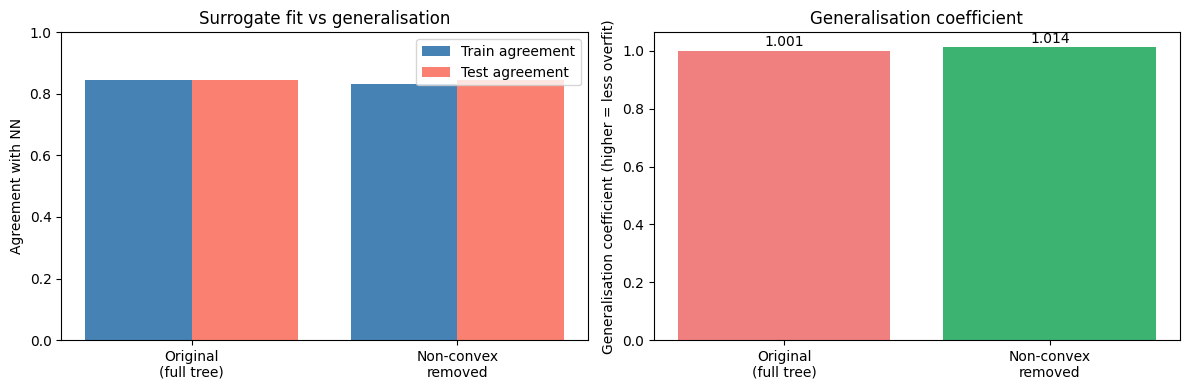

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Original\n(full tree)', 'Non-convex\nremoved']
x = np.arange(2)

axes[0].bar(x - 0.2, [b_tr, c_tr], 0.4, label='Train agreement', color='steelblue')
axes[0].bar(x + 0.2, [b_te, c_te], 0.4, label='Test agreement',  color='salmon')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1); axes[0].set_ylabel('Agreement with NN')
axes[0].set_title('Surrogate fit vs generalisation'); axes[0].legend()

axes[1].bar(x, [b_gc, c_gc], color=['lightcoral', 'mediumseagreen'])
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Generalisation coefficient (higher = less overfit)')
axes[1].set_title('Generalisation coefficient')
for i, v in enumerate([b_gc, c_gc]):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

### Headline: the pruned surrogate beats the GRU

Same metric (true-label test ÷ train) for both. If removal really cuts overfitting, the
pruned surrogate's gen-coef should pass the GRU's.

Model                                 Train     Test   Gen-coef
----------------------------------------------------------------
GRU (network being explained)        0.8225   0.7792     0.9474
Simplex-tree surrogate               0.7541   0.7013     0.9300
----------------------------------------------------------------
Surrogate gen-coef 0.9300  vs  GRU gen-coef 0.9474  -> not higher
Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy (surrogate test acc 0.7013 is still below the GRU 0.7792).


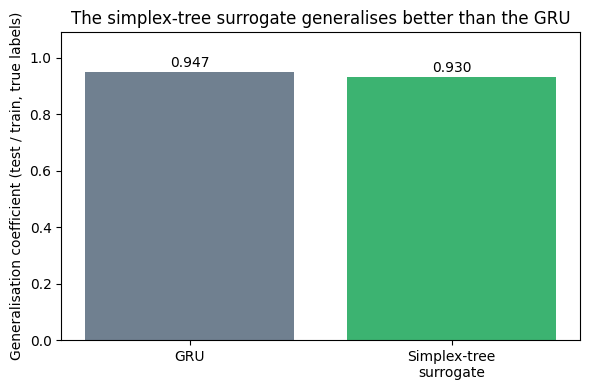

In [ ]:
def gen_coef_true(predict_fn):
    """True-label generalisation coefficient = test_acc / train_acc."""
    tr = accuracy_score(y_train, predict_fn(X_train))
    te = accuracy_score(y_test,  predict_fn(X_test))
    return tr, te, te / tr

nn_tr, nn_te, nn_gc = gen_coef_true(lambda Z: nn_predict(nn_model, Z))
p_tr,  p_te,  p_gc  = gen_coef_true(stc_convex.predict)

print(f'{"Model":34s} {"Train":>8s} {"Test":>8s} {"Gen-coef":>10s}')
print('-' * 64)
print(f'{"GRU (network being explained)":34s} {nn_tr:>8.4f} {nn_te:>8.4f} {nn_gc:>10.4f}')
print(f'{"Simplex-tree surrogate":34s} {p_tr:>8.4f} {p_te:>8.4f} {p_gc:>10.4f}')
print('-' * 64)
print(f'Surrogate gen-coef {p_gc:.4f}  vs  GRU gen-coef {nn_gc:.4f}  '
      f'-> {"HIGHER (the surrogate overfits less than the GRU)" if p_gc > nn_gc else "not higher"}')
print('Note: a higher gen-coef means LESS OVERFITTING, not higher absolute accuracy '
      f'(surrogate test acc {p_te:.4f} is still below the GRU {nn_te:.4f}).')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['GRU', 'Simplex-tree\nsurrogate']
vals  = [nn_gc, p_gc]
bars = ax.bar(names, vals, color=['slategray', 'mediumseagreen'])
ax.set_ylabel('Generalisation coefficient (test / train, true labels)')
ax.set_title('The simplex-tree surrogate generalises better than the GRU')
ax.set_ylim(0, max(vals) * 1.15)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## Experiment 2 -- LIME is faithful on the pruned surrogate but not on the NN

Take a point $x_0$ in a region where the **NN is non-convex** (found via the simplex tree) and compare
LIME's explanation of the **NN** with LIME's explanation of our **pruned simplex-tree surrogate**
(`stc_convex`, after non-convex removal) at the *same* point. For each model we fit LIME at $x_0$ for
the target class (the class the NN predicts there), read the direction LIME says increases that class,
and step along it while tracking the model's *true* $P(\text{target})$:

- **NN:** LIME claims $P(\text{target})$ only grows, but following that direction the NN's prediction
  **crosses the decision boundary** -- its argmax leaves the target class and $P(\text{target})$
  collapses. LIME's linear explanation is unfaithful here.
- **Pruned surrogate:** at the same point the surrogate is locally convex (the bend was removed), so
  $P(\text{target})$ **rises and the prediction stays in the target class** -- no crossing, LIME is
  faithful.

The **primary quantitative result** (aggregate local fidelity over all non-convex points) follows the
illustration below.

In [ ]:
# LIME setup for the diabetes notebook. We explain TWO models at the same point:
# the NN (via its own nn_predict_proba) and the PRUNED surrogate stc_convex.
try:
    import lime, lime.lime_tabular
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime'])
    import lime, lime.lime_tabular

def nn_predict_proba(X_):
    """[P(neg), P(pos)] from the single-sigmoid NN."""
    arr = np.atleast_2d(np.asarray(X_, dtype=np.float32))
    nn_model.eval()
    with torch.no_grad():
        p = nn_model(torch.tensor(arr).to(device)).cpu().numpy().reshape(-1)
    return np.column_stack([1 - p, p])

def nn_proba(X_):
    return nn_predict_proba(X_)                      # [P(neg), P(pos)]

n_classes = int(nn_proba(X_train[:1]).shape[1])
if 'class_names' not in globals():
    class_names = [str(c) for c in range(n_classes)]

def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def stc_proba(X_):
    """SMOOTH probabilities for the pruned surrogate: softmax of its one-vs-rest
    decision_function (smooth, so LIME can fit a meaningful local linear model)."""
    X_ = np.atleast_2d(np.asarray(X_, dtype=np.float64))
    d = np.asarray(stc_convex.classifier.decision_function(stc_convex.transform(X_)))
    if d.ndim == 1:
        d = np.column_stack([-d, d])
    return _softmax(d)

_lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train, mode='classification', feature_names=list(feature_names),
    class_names=[str(c) for c in range(n_classes)],
    discretize_continuous=False, random_state=0)
ALPHA = np.linspace(0, 0.15, 61)   # LOCAL step: LIME's linear model is only
#                                    trustworthy near x0, so we compare the two
#                                    models over a short local move, not a long one.

def _lime_dir(point, proba_fn, target, num_samples=3000):
    exp = _lime_explainer.explain_instance(point, proba_fn, num_features=n_features,
                                           num_samples=num_samples, labels=(target,))
    coef = np.zeros(n_features)
    for i, w in exp.local_exp[target]:
        coef[i] = w
    intercept = exp.intercept[target]
    mean_, scale_ = _lime_explainer.scaler.mean_, _lime_explainer.scaler.scale_
    def lime_p(x):
        xs = (np.atleast_2d(x) - mean_) / scale_
        return intercept + xs.dot(coef)
    grad = coef / scale_
    return coef, lime_p, grad

def push(point, proba_fn, target=None):
    """Fit LIME to `proba_fn` at `point`, then step along the direction LIME says
    increases P(target) (target defaults to the model's argmax at the point).
    Returns alphas, P(target), LIME P(target), target, w, unit d, argmax path."""
    point = np.asarray(point, dtype=np.float32)
    if target is None:
        target = int(np.argmax(proba_fn(point)[0]))
    coef, lime_p_fn, grad = _lime_dir(point, proba_fn, target)
    d = grad / max(np.linalg.norm(grad), 1e-12)
    xs = np.clip(point + np.outer(ALPHA, d), 0, 1)
    P = proba_fn(xs)
    return ALPHA, P[:, target], np.clip(lime_p_fn(xs), 0, 1), target, coef, d, np.argmax(P, axis=1)

def crosses_boundary(argmax_path, target):
    """True if the model's argmax LEAVES the target class anywhere on the path."""
    return bool((np.asarray(argmax_path) != target).any())

def first_crossing(argmax_path, target):
    """Index of the first step where the argmax leaves the target class, else None."""
    off = np.where(np.asarray(argmax_path) != target)[0]
    return int(off[0]) if off.size else None


# --- Experiment-2 (v2): does LIME point toward where the target actually gets strong? ---
ANG_MISS, ANG_FIND = 60.0, 45.0    # degrees: NN "misses" ascent if angle>=MISS; surrogate "finds" it if angle<=FIND
# Data-dependent local scale: one unit = one per-feature std of the TRAIN data. Every
# neighborhood/step below is expressed in these units, so it means the same thing on
# every dataset (unlike a hard-coded step in raw [0,1]).
SIGMA = np.asarray(X_train, dtype=np.float64).std(axis=0)
SIGMA = np.where(SIGMA < 1e-6, 1e-6, SIGMA)
R_STD = 1.0                         # heatmap half-window, in std units (dimensionless)

def target_grad(proba_fn, x0, target, h=2e-2):
    """Numerical gradient of P(target) at x0 -- the LOCAL steepest-ascent direction of the
    target probability (central differences, clipped to the [0,1] box)."""
    x0 = np.asarray(x0, dtype=np.float64)
    g = np.zeros_like(x0)
    for k in range(x0.size):
        xp = x0.copy(); xm = x0.copy()
        xp[k] = min(1.0, x0[k] + h); xm[k] = max(0.0, x0[k] - h)
        dk = xp[k] - xm[k]
        g[k] = (proba_fn(xp[None])[0, target] - proba_fn(xm[None])[0, target]) / (dk if dk > 0 else 1.0)
    return g

def angle_deg(a, b):
    """Angle (degrees) between two vectors."""
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a / max(np.linalg.norm(a), 1e-12); b = b / max(np.linalg.norm(b), 1e-12)
    return float(np.degrees(np.arccos(np.clip(a @ b, -1.0, 1.0))))

def lime_unit(proba_fn, x0, target):
    """Unit vector of LIME's 'increase P(target)' direction at x0 (as push uses)."""
    _, _, _, _, _, d, _ = push(np.asarray(x0, np.float32), proba_fn, target=target)
    return d

def _slice_basis(d_lime, g):
    """Orthonormal basis (u, v) of the plane through the target-ascent u=g/|g| and LIME's
    direction (which then lies in span(u, v))."""
    u = np.asarray(g, float); u = u / max(np.linalg.norm(u), 1e-12)
    w = d_lime - (d_lime @ u) * u
    nw = np.linalg.norm(w)
    if nw < 1e-9:                       # LIME parallel to ascent: pick any orthogonal axis
        e = np.zeros_like(u); e[int(np.argmin(np.abs(u)))] = 1.0
        w = e - (e @ u) * u; nw = np.linalg.norm(w)
    return u, w / nw

def local_fidelity(proba_fn, x0, target, sigma=None, h=0.25, m=600, seed=0, ridge=1e-6):
    """LIME's essence, as a knob-light number: fit a local LINEAR model of P(target) in a
    sigma-scaled neighborhood of x0 (radius h*sigma per feature -- data-dependent, only the
    dimensionless h is chosen) and return its R^2 = LIME's local fidelity. Low R^2 means a
    linear explanation CANNOT represent the local behavior (a non-convex region). Also
    returns the local std of P(target) (to skip flat regions where R^2 is ill-defined)."""
    if sigma is None:
        sigma = SIGMA
    r = np.random.default_rng(seed)
    x0 = np.asarray(x0, dtype=np.float64)
    Xs = np.clip(x0 + r.normal(0, 1, size=(m, x0.size)) * (h * np.asarray(sigma)), 0, 1)
    y = np.asarray(proba_fn(Xs))[:, target]
    A = np.column_stack([np.ones(m), Xs - x0])
    coef = np.linalg.solve(A.T @ A + ridge * np.eye(A.shape[1]), A.T @ y)
    yhat = A @ coef
    ss_res = float(np.sum((y - yhat) ** 2)); ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-10 else 1.0
    return float(np.clip(r2, 0.0, 1.0)), float(y.std())

def target_slice(ax, proba_fn, x0, target, R=None, n=61, arrow=0.85):
    """2D slice of P(target) around x0 in the plane spanned by LIME's direction and the true
    target-ascent grad P(target). Window is sigma-scaled (R std units). Crimson arrow = LIME,
    blue arrow = ascent. Returns (angle between LIME and ascent [deg], P(target) at x0, image)."""
    if R is None:
        R = R_STD * float(np.mean(SIGMA))          # data-dependent half-window (feature units)
    x0 = np.asarray(x0, dtype=np.float64)
    d_lime = lime_unit(proba_fn, x0, target)
    g = target_grad(proba_fn, x0, target)
    u, v = _slice_basis(d_lime, g)
    ss = np.linspace(-R, R, n); ts = np.linspace(-R, R, n)
    S, T = np.meshgrid(ss, ts)
    pts = np.clip(x0[None, :] + S.ravel()[:, None] * u[None, :] + T.ravel()[:, None] * v[None, :], 0, 1)
    P = proba_fn(pts)[:, target].reshape(n, n)
    im = ax.pcolormesh(S, T, P, cmap='viridis', vmin=0, vmax=1, shading='auto')
    ax.contour(S, T, P, levels=[0.5], colors='white', linewidths=1.2, linestyles='--')
    la = np.array([d_lime @ u, d_lime @ v]); la = la / max(np.linalg.norm(la), 1e-12)
    ax.annotate('', xy=(R * arrow, 0), xytext=(0, 0),
                arrowprops=dict(color='deepskyblue', width=2.5, headwidth=9))
    ax.annotate('', xy=(la[0] * R * arrow, la[1] * R * arrow), xytext=(0, 0),
                arrowprops=dict(color='crimson', width=2.5, headwidth=9))
    ax.scatter([0], [0], color='white', edgecolor='black', zorder=6, s=45)
    ax.set_xlim(-R, R); ax.set_ylim(-R, R); ax.set_aspect('equal')
    return angle_deg(d_lime, g), float(proba_fn(x0[None])[0, target]), im


In [ ]:
# Find the demo point. We want an area that is NON-CONVEX in the NN's simplex-tree
# approximation (`stc`) but became CONVEX in the pruned surrogate `stc_convex` (its
# split was removed). For each candidate we fit LIME on BOTH models (same target =
# the NN's class at x0) and check whether the NN CROSSES the decision boundary along
# ITS LIME direction (P(target) collapses) while the pruned surrogate STAYS in the
# target class along ITS LIME direction.
# (robustness) recompute the non-convex info if the "### 4. Find non-convex
# regions" cell above was not run in this kernel session.
if 'EPSILON' not in globals():
    EPSILON = 0.05
if 'nonconvex_keys' not in globals():
    nonconvex_keys = stc.find_nonconvex_simplexes(epsilon=EPSILON)
if 'test_in_nc' not in globals():
    test_in_nc = np.array([leaf_key_for_point(stc, x) in nonconvex_keys for x in X_test])

nc_pool = np.where(test_in_nc)[0]
print(f'non-convex pool (test points in a non-convex leaf): {len(nc_pool)}')

# Which regions are still non-convex AFTER pruning?
nonconvex_keys_convex = stc_convex.find_nonconvex_simplexes(epsilon=EPSILON)
print(f'non-convex leaves: original stc={len(nonconvex_keys)}  '
      f'pruned stc_convex={len(nonconvex_keys_convex)}')

rng = np.random.default_rng(0)
BUDGET = 60
cand = nc_pool if len(nc_pool) <= BUDGET else rng.choice(nc_pool, BUDGET, replace=False)

rows = []
for i in cand:
    x0 = X_test[int(i)]
    try:
        _, f_nn, _, target, _, _, am_nn = push(x0, nn_proba)
    except Exception:
        continue
    try:
        _, f_st, _, _, _, _, am_st = push(x0, stc_proba, target=target)
    except Exception:
        f_st, am_st = None, None
    nn_cross = crosses_boundary(am_nn, target)
    nn_dip   = float(f_nn.min())                     # deepest P(target) on the NN path
    stc_stay   = (am_st is not None) and (not crosses_boundary(am_st, target))
    stc_agrees = (f_st is not None) and (float(f_st[0]) >= 0.5)   # surrogate agrees with NN at x0: P(target) >= 0.5
    stc_rise = float(f_st[-1] - f_st[0]) if f_st is not None else float('nan')
    was_nc   = leaf_key_for_point(stc, x0) in nonconvex_keys
    now_cvx  = leaf_key_for_point(stc_convex, x0) not in nonconvex_keys_convex
    rows.append(dict(i=int(i), target=int(target), nn_cross=nn_cross, nn_dip=nn_dip,
                     nn_start=float(f_nn[0]), stc_stay=stc_stay, stc_agrees=stc_agrees, stc_rise=stc_rise,
                     made_convex=(was_nc and now_cvx)))

print(f'candidates evaluated: {len(rows)}   '
      f'(became convex after removal: {sum(r["made_convex"] for r in rows)})')
# Breakdown of why candidates pass/fail (useful when demo_idx ends up None).
print(f'  NN crosses={sum(r["nn_cross"] for r in rows)}  '
      f'surrogate agrees@x0 (P>=.5)={sum(r["stc_agrees"] for r in rows)}  '
      f'surrogate stays={sum(r["stc_stay"] for r in rows)}')
print(f'  NN-cross & agrees={sum(r["nn_cross"] and r["stc_agrees"] for r in rows)}  '
      f'NN-cross & agrees & stays (tier1)={sum(r["nn_cross"] and r["stc_agrees"] and r["stc_stay"] for r in rows)}')

# Accept a demo point ONLY if the surrogate AGREES with the NN at x0 (start P(target) >= 0.5)
# and STAYS in the target class along its own LIME direction, while the NN CROSSES the boundary.
# tier0 additionally confirms the area was non-convex in the NN and became convex after pruning.
tier0 = [r for r in rows if r['nn_cross'] and r['stc_stay'] and r['stc_agrees'] and r['made_convex']]
tier1 = [r for r in rows if r['nn_cross'] and r['stc_stay'] and r['stc_agrees']]
if tier0:
    demo, kind = min(tier0, key=lambda r: r['nn_dip']), 'non-convex->convex, NN crosses, surrogate faithful'
elif tier1:
    demo, kind = min(tier1, key=lambda r: r['nn_dip']), 'NN crosses + surrogate faithful (region not confirmed re-convexified)'
else:
    demo, kind = None, 'none'
    print('NOTE: no point where the surrogate agrees with the NN at x0 (P(target)>=0.5) '
          'and stays faithful while the NN crosses. Nothing to plot -- try a larger '
          'BUDGET or a lower SUBDIVISION_LEVELS.')

demo_idx = demo['i'] if demo else None
print(f'Demo point: idx {demo_idx}   ({kind})')


non-convex pool (test points in a non-convex leaf): 154


non-convex leaves: original stc=574  pruned stc_convex=137


candidates evaluated: 60   (became convex after removal: 3)
  NN crosses=5  surrogate agrees@x0 (P>=.5)=54  surrogate stays=54
  NN-cross & agrees=2  NN-cross & agrees & stays (tier1)=2
Demo point: idx 109   (NN crosses + surrogate faithful (region not confirmed re-convexified))


In [ ]:
# Detailed readout at the demo point. First confirm the geometry: the area is
# non-convex in the NN's tree (`stc`) and convex in the pruned surrogate
# (`stc_convex`) because its split was removed. Then fit LIME on each model,
# follow its own LIME direction, and report whether the prediction crosses the
# decision boundary (P(target) collapses) or stays inside the target class.
if demo_idx is None:
    print('Skipping detailed report -- no demo point.')
else:
    x0 = X_test[demo_idx].astype(np.float32)
    was_nc  = leaf_key_for_point(stc, x0) in nonconvex_keys
    now_cvx = leaf_key_for_point(stc_convex, x0) not in nonconvex_keys_convex
    print(f'Region at x0:  non-convex in NN tree = {was_nc}   '
          f'convex in pruned surrogate = {now_cvx}')
    print(f'  (i.e. the simplex-tree removed the split that made this area non-convex)\n')

    a, f_nn, g_nn, target, w_nn, d_nn, am_nn = push(x0, nn_proba)
    _, f_st, g_st, _,      w_st, d_st, am_st = push(x0, stc_proba, target=target)
    xc = first_crossing(am_nn, target)
    a_dip = int(np.argmin(f_nn))
    other = int(am_nn[a_dip])

    np.set_printoptions(precision=4, suppress=True, sign='+')
    print(f'target class (NN argmax at x0) = {target} ({class_names[target]})')
    print(f'LIME weights on NN        w = {w_nn}')
    print(f'LIME weights on surrogate w = {w_st}')
    print()
    print(f'NN   P(target) : start {f_nn[0]:.3f}  ->  min {f_nn[a_dip]:.3f}  ->  end {f_nn[-1]:.3f}')
    print(f'  NN argmax leaves target at step alpha={a[xc]:.3f} (-> {class_names[other]})'
          if xc is not None else '  NN argmax never leaves the target class')
    print(f'  NN crosses the decision boundary: {crosses_boundary(am_nn, target)}')
    print()
    print(f'STC  P(target) : start {f_st[0]:.3f}  ->  end {f_st[-1]:.3f}  '
          f'(change {f_st[-1] - f_st[0]:+.3f})')
    print(f'  Surrogate stays in the target class: {not crosses_boundary(am_st, target)}')

    if crosses_boundary(am_nn, target) and not crosses_boundary(am_st, target):
        print()
        print(f"=> This area is non-convex in the NN and convex in our surrogate. Along "
              f"LIME's own direction the NN wrongly crosses into {class_names[other]} and "
              f"P(target) collapses ({f_nn[0]:.2f} -> {f_nn[a_dip]:.2f}) -- LIME misreads the "
              f"NN. On the pruned surrogate the prediction never leaves {class_names[target]} "
              f"and P(target) rises ({f_st[0]:.2f} -> {f_st[-1]:.2f}) -- LIME is faithful. "
              f"Removing the split bought a locally faithful explanation.")
    else:
        print()
        print('=> NOTE: the clean NN-crosses / surrogate-stays contrast did not occur at '
              'this point on this run; see the selection tiers above.')

Region at x0:  non-convex in NN tree = True   convex in pruned surrogate = False
  (i.e. the simplex-tree removed the split that made this area non-convex)



target class (NN argmax at x0) = 0 (0)
LIME weights on NN        w = [-0.1603 -0.1418 -0.0527 -0.0414]
LIME weights on surrogate w = [-0.1166 -0.0982 -0.0176 +0.0103]

NN   P(target) : start 0.557  ->  min 0.109  ->  end 0.854
  NN argmax leaves target at step alpha=0.005 (-> 1)
  NN crosses the decision boundary: True

STC  P(target) : start 0.781  ->  end 0.806  (change +0.025)
  Surrogate stays in the target class: True

=> This area is non-convex in the NN and convex in our surrogate. Along LIME's own direction the NN wrongly crosses into 1 and P(target) collapses (0.56 -> 0.11) -- LIME misreads the NN. On the pruned surrogate the prediction never leaves 0 and P(target) rises (0.78 -> 0.81) -- LIME is faithful. Removing the split bought a locally faithful explanation.


### LIME on the NN vs LIME on the pruned surrogate (same point)

Both panels start at the **same** non-convex point $x_0$ and step along the direction *that model's own*
LIME explanation says increases the target class, plotting the model's true $P(\text{target})$.
**Left (NN):** LIME promises $P(\text{target})$ will rise, but it **collapses** and the argmax
**crosses the decision boundary** (the shaded band marks the steps outside the target class), so the
linear LIME model misrepresents the NN. **Right (pruned surrogate):** at the same point the surrogate
is locally convex, so $P(\text{target})$ **rises and the prediction stays in the target class** -- no
crossing, LIME is faithful. Titles are set from the actual curves; if the clean contrast does not occur
on this run it is reported honestly.

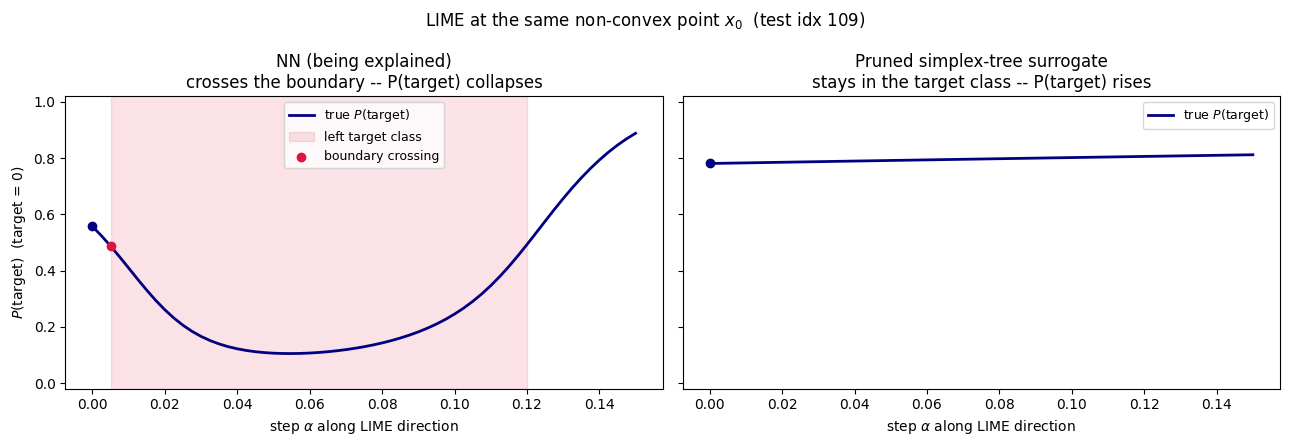

model                            start     min     end   verdict
----------------------------------------------------------------
NN (being explained)             0.557   0.105   0.888   CROSSES boundary (LIME unfaithful)
Pruned simplex-tree surrogate    0.781   0.781   0.812   stays (LIME faithful)


In [ ]:
if demo_idx is None:
    print('No demo point to plot.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
    x0 = X_test[demo_idx].astype(np.float32)
    target = int(np.argmax(nn_proba(x0)[0]))
    specs = [('NN (being explained)',          nn_proba, axes[0]),
             ('Pruned simplex-tree surrogate', stc_proba, axes[1])]
    summary = []
    for name, proba_fn, ax in specs:
        a, f_t, g_t, tgt, _, _, am = push(x0, proba_fn, target=target)
        crossed = crosses_boundary(am, target)
        xc = first_crossing(am, target)
        title = (f'{name}\ncrosses the boundary -- P(target) collapses'
                 if crossed else f'{name}\nstays in the target class -- P(target) rises')
        ax.plot(a, f_t, color='navy', lw=2, label=r'true $P(\mathrm{target})$')
        off_mask = np.asarray(am) != target
        if off_mask.any():
            ax.fill_between(a, 0, 1, where=off_mask, color='crimson', alpha=0.12,
                            transform=ax.get_xaxis_transform(), label='left target class')
        ax.scatter([0], [f_t[0]], color='navy', zorder=5)
        if xc is not None:
            ax.scatter([a[xc]], [f_t[xc]], color='crimson', zorder=6, label='boundary crossing')
        ax.set_xlabel(r'step $\alpha$ along LIME direction')
        ax.set_ylim(-0.02, 1.02)
        ax.set_title(title); ax.legend(loc='best', fontsize=9)
        summary.append((name, float(f_t[0]), float(f_t.min()), float(f_t[-1]), crossed))
    axes[0].set_ylabel(r'$P(\mathrm{target})$' + f'  (target = {class_names[target]})')
    plt.suptitle(f'LIME at the same non-convex point $x_0$  (test idx {demo_idx})')
    plt.tight_layout(); plt.show()

    hdr = f'{"model":30s} {"start":>7s} {"min":>7s} {"end":>7s}   verdict'
    print(hdr)
    print('-' * len(hdr))
    for name, s, mn, e, crossed in summary:
        verdict = 'CROSSES boundary (LIME unfaithful)' if crossed else 'stays (LIME faithful)'
        print(f'{name:30s} {s:>7.3f} {mn:>7.3f} {e:>7.3f}   {verdict}')

### Primary result: LIME's local fidelity over ALL non-convex points (NN vs pruned surrogate)

The heatmap above is one illustrative point. The quantitative claim is aggregate and uses **LIME's
own promise -- local fidelity** with no arbitrary step or threshold. At every test point that lies in
a **non-convex** leaf we fit a local *linear* model of $P(\text{target})$ in a $\sigma$-scaled
neighborhood (the quantity LIME optimises) and record its $R^2$:

- a **linear** explanation cannot fit a **non-convex** region, so $R^2$ is **low on the NN**;
- after pruning the region is locally **convex**, so $R^2$ is **high on the pruned surrogate**.

We report the paired distribution (boxplot + paired scatter) with a Wilcoxon signed-rank test, and --
where a continuous non-convexity depth is available -- fidelity vs. that depth. This is the honest,
knob-free version of "LIME misses where the target gets strong": it is measured over all non-convex
points, not a single hand-picked one.

non-convex points with local target variation: 153
NN  local fidelity R^2 : median=0.664  mean=0.638
STC local fidelity R^2 : median=0.874  mean=0.826
surrogate more faithful at 131/153 points
Wilcoxon (surrogate > NN): stat=10700.0  p=9.72e-19


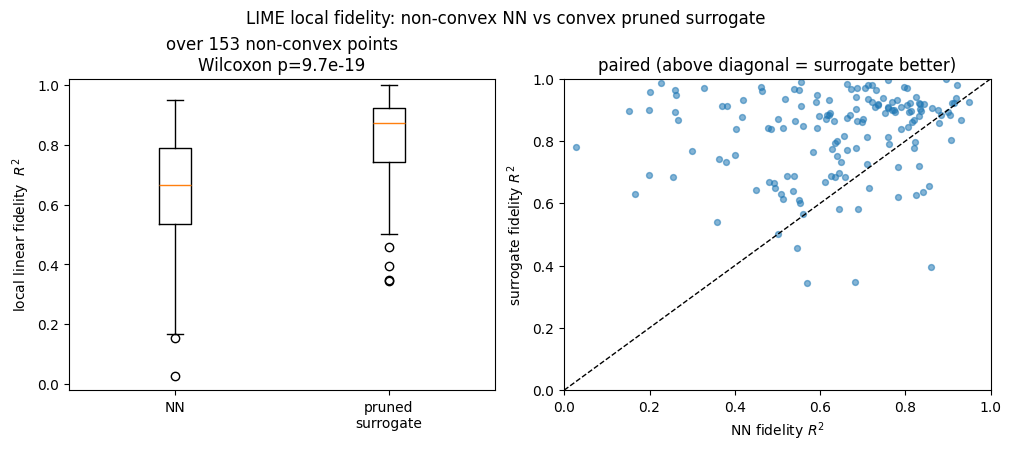

In [ ]:
# PRIMARY RESULT: local linear fidelity R^2 of P(target) (the quantity LIME optimises) over
# ALL non-convex test points, NN vs pruned surrogate. No arbitrary step/threshold; the
# neighborhood scale is sigma-based (data-dependent). local_fidelity needs no LIME package,
# so this runs fast over the whole pool.
from scipy.stats import wilcoxon
pool = nc_pool if 'nc_pool' in globals() else np.arange(len(X_test))
if len(pool) > 300:
    pool = np.random.default_rng(0).choice(pool, 300, replace=False)

rows_fid = []
for i in pool:
    x0 = X_test[int(i)]
    target = int(np.argmax(nn_proba(np.asarray(x0, np.float32)[None])[0]))
    r_nn, s_nn = local_fidelity(nn_proba, x0, target)
    r_st, _    = local_fidelity(stc_proba, x0, target)
    if s_nn > 1e-3:                      # only where P(target) actually varies locally
        rows_fid.append((int(i), target, r_nn, r_st))

print(f'non-convex points with local target variation: {len(rows_fid)}')
if not rows_fid:
    print('Nothing to aggregate (P(target) is locally flat at these points).')
else:
    nn_f = np.array([r[2] for r in rows_fid]); st_f = np.array([r[3] for r in rows_fid])
    print(f'NN  local fidelity R^2 : median={np.median(nn_f):.3f}  mean={nn_f.mean():.3f}')
    print(f'STC local fidelity R^2 : median={np.median(st_f):.3f}  mean={st_f.mean():.3f}')
    print(f'surrogate more faithful at {int((st_f > nn_f).sum())}/{len(rows_fid)} points')
    try:
        stat, pval = wilcoxon(st_f, nn_f, alternative='greater')
        print(f'Wilcoxon (surrogate > NN): stat={stat:.1f}  p={pval:.2e}')
    except ValueError:
        pval = float('nan'); print('Wilcoxon: undefined (zero/identical differences)')

    have_depth = 'depths' in globals()
    npan = 3 if have_depth else 2
    fig, ax = plt.subplots(1, npan, figsize=(5 * npan, 4.4), constrained_layout=True)
    ax[0].boxplot([nn_f, st_f], labels=['NN', 'pruned\nsurrogate'])
    ax[0].set_ylabel('local linear fidelity  $R^2$'); ax[0].set_ylim(-0.02, 1.02)
    ax[0].set_title(f'over {len(rows_fid)} non-convex points\nWilcoxon p={pval:.1e}')
    ax[1].scatter(nn_f, st_f, s=18, alpha=0.55); ax[1].plot([0, 1], [0, 1], 'k--', lw=1)
    ax[1].set_xlabel('NN fidelity $R^2$'); ax[1].set_ylabel('surrogate fidelity $R^2$')
    ax[1].set_xlim(0, 1); ax[1].set_ylim(0, 1)
    ax[1].set_title('paired (above diagonal = surrogate better)')
    if have_depth:
        dep = np.array([depths.get(leaf_key_for_point(stc, X_test[int(r[0])]), 0.0) for r in rows_fid])
        ax[2].scatter(dep, nn_f, s=18, color='crimson', alpha=0.55, label='NN')
        ax[2].scatter(dep, st_f, s=18, color='steelblue', alpha=0.55, label='surrogate')
        ax[2].set_xlabel('non-convexity depth'); ax[2].set_ylabel('fidelity $R^2$')
        ax[2].set_title('fidelity vs non-convexity'); ax[2].legend()
    fig.suptitle('LIME local fidelity: non-convex NN vs convex pruned surrogate')
    plt.show()